In [13]:
from sacrebleu.metrics import BLEU
import re
import itertools
from nltk.tokenize import sent_tokenize
import os
import json
from scipy import stats
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../..')
from style_setup import set_thesis_style
set_thesis_style()


# Analysis functions

In [14]:
# Ensure NLTK's sentence tokenizer is downloaded
try:
    import nltk
    nltk.data.find('tokenizers/punkt')
except (ImportError, nltk.downloader.DownloadError):
    nltk.download('punkt')

In [15]:
def remove_markdown(text):
    """Removes markdown formatting (#, *) from text."""
    text = re.sub(r'#+', '', text)
    text = re.sub(r'\*\*', '', text)
    text = re.sub(r'\*', '', text)
    return text.strip()

def is_valid_sentence(sentence):
    """
    Checks if a sentence is valid for analysis.
    - Not empty
    - Not just a numbered list marker (e.g., "1.", "2.")
    - Longer than 3 characters after cleaning
    """
    sentence = sentence.strip()
    if not sentence:
        return False
    
    cleaned = remove_markdown(sentence)
    
    # Check for numbered list markers like "1." or "### 8."
    if cleaned.replace('.', '').isdigit():
        return False
    
    # Check if sentence is too short
    if len(cleaned) < 3:
        return False
        
    # Check for patterns like "1." with no further content
    if cleaned.endswith('.') and cleaned[:-1].isdigit():
        return False
    
    return True

def calculate_self_bleu(sentences, n_gram=4):
    """
    Calculates the Self-BLEU score for a list of sentences.
    
    Returns 100.0 if there are fewer than two sentences, as there is no diversity to measure.
    """
    if len(sentences) < 2:
        return 100.0  # Assign max score (min diversity) if not enough sentences
    
    bleu = BLEU(max_ngram_order=n_gram, effective_order=True)
    scores = []
    
    for i in range(len(sentences)):
        hypothesis = [sentences[i]]
        references = [[s] for j, s in enumerate(sentences) if i != j]
        score = bleu.corpus_score(hypothesis, references)
        scores.append(score.score)
        
    return sum(scores) / len(scores)

def load_and_clean_responses(file_path):
    """Loads and preprocesses responses from a JSONL file."""
    responses = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            if "response_model" in data and data["response_model"]:
                responses.append(data["response_model"])

    clean_responses = []
    for resp in responses:
        sentences = sent_tokenize(resp)
        valid_sentences = [s for s in sentences if is_valid_sentence(s)]
        clean_sentences = [remove_markdown(s) for s in valid_sentences]
        # Only include sentences with at least 4 words
        final_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
        if final_sentences:
            clean_responses.append(final_sentences)
            
    return clean_responses

In [16]:
def calculate_self_bleu_scores(
    data_paths,
    output_dir_template,
    mode,
    sample_number,
    save=False,
    n_gram=4,
    seed=42
):
    """
    Calculates Self-BLEU scores for a list of sentences.
    
    Returns 100.0 if there are fewer than two sentences, as there is no diversity to measure.
    """
    if mode not in ['individual', 'aggregated']:
        raise ValueError("Mode must be 'individual' or 'aggregated'.")

    # The main seed is now used as a base, and we will derive a specific seed for each file
    output_base_dir = output_dir_template.format(mode=mode, n_gram=n_gram)
    
    print(f"--- Running Self-BLEU Calculation (Mode: {mode}, N-gram: {n_gram}) ---")

    for size, file_paths in data_paths.items():
        print(f"Processing {size} models...")
        size_dir = os.path.join(output_base_dir, size)
        if save:
            os.makedirs(size_dir, exist_ok=True)

        # Enumerate over the file_paths to get a stable index for each file
        for i, file_path in enumerate(tqdm(file_paths, desc=f"  Files for {size}")):
            # Set a deterministic seed for each file to ensure reproducible sampling
            # The seed is based on the main seed and the file's position in the list
            np.random.seed(seed + i)

            model_name = os.path.splitext(os.path.basename(file_path))[0]
            
            clean_responses = load_and_clean_responses(file_path)
            
            # For aggregated mode, filter to responses with at least 2 sentences
            # to maintain consistency with the individual calculation pool.
            if mode == 'aggregated':
                eligible_responses = [r for r in clean_responses if len(r) >= 2]
            else:
                eligible_responses = clean_responses
                
            if len(eligible_responses) < sample_number:
                print(f"\nWarning: Only {len(eligible_responses)} eligible responses found for {model_name} (requested {sample_number}). Using all available.")
                response_samples = eligible_responses
            else:
                indices = np.random.choice(len(eligible_responses), size=sample_number, replace=False)
                response_samples = [eligible_responses[i] for i in indices]

            # --- Score Calculation ---
            if mode == 'individual':
                scores = [calculate_self_bleu(sample, n_gram) for sample in response_samples if len(sample) >= 2]
                if not scores:
                    print(f"Warning: No valid samples to calculate individual scores for {model_name}.")
                    continue
                avg_self_bleu = np.mean(scores)
                lex_div_scores = [100 - s for s in scores]
                avg_lex_div = np.mean(lex_div_scores)
            else: # aggregated mode
                all_sentences = [s for resp in response_samples for s in resp]
                avg_self_bleu = calculate_self_bleu(all_sentences, n_gram)
                avg_lex_div = 100 - avg_self_bleu

            # --- Result Saving ---
            if save:
                output_file = os.path.join(size_dir, f"{model_name}_self_bleu.jsonl")
                entry = {
                    "source": model_name,
                    "size": size,
                    f"average_self_bleu_{n_gram}": avg_self_bleu,
                    "average_lexical_diversity": avg_lex_div,
                }
                if mode == 'individual':
                    entry["lexical_diversity_scores"] = lex_div_scores
                
                with open(output_file, 'w') as f:
                    f.write(json.dumps(entry) + '\n')
    
    print("--- Calculation complete. ---")

# Run code

## Small models

In [17]:
# --- Configuration ---
N_GRAM = 3
SAMPLE_NUMBER = 1500
SAVE_RESULTS = True
BASE_DATA_DIR = "/Users/maxschaffelder/Desktop/Thesis/data/exp_1"
MODEL_SIZE = "small"

# Using new, corrected file paths
model_paths = {
    "Small": [
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_lora_llama_8b_single.jsonl",
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_lora_llama_8b_multi.jsonl",
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_lora_llama_8b_human.jsonl",
        "/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_test_Llama.jsonl"
    ],
    # Add paths for "Medium" and "Large" models here if needed
}

output_dir_template = f"{BASE_DATA_DIR}/{MODEL_SIZE}/lex_div/self_bleu_{{mode}}_{{n_gram}}"

# --- Run Calculations ---
# Calculate scores for individual responses
calculate_self_bleu_scores(
    data_paths=model_paths,
    output_dir_template=output_dir_template,
    mode='individual',
    sample_number=SAMPLE_NUMBER,
    save=SAVE_RESULTS,
    n_gram=N_GRAM
)

# Calculate scores for aggregated responses
calculate_self_bleu_scores(
    data_paths=model_paths,
    output_dir_template=output_dir_template,
    mode='aggregated',
    sample_number=100,  # Using 100 for aggregated as in original code
    save=SAVE_RESULTS,
    n_gram=N_GRAM
)

--- Running Self-BLEU Calculation (Mode: individual, N-gram: 3) ---
Processing Small models...


  Files for Small:  25%|██▌       | 1/4 [00:06<00:20,  6.85s/it]

  Files for Small:  50%|█████     | 2/4 [00:13<00:13,  6.74s/it]

  Files for Small:  75%|███████▌  | 3/4 [00:16<00:05,  5.18s/it]

  Files for Small: 100%|██████████| 4/4 [00:23<00:00,  5.83s/it]


--- Calculation complete. ---
--- Running Self-BLEU Calculation (Mode: aggregated, N-gram: 3) ---
Processing Small models...


  Files for Small: 100%|██████████| 4/4 [02:22<00:00, 35.60s/it]

--- Calculation complete. ---


--- Lexical Diversity Scores Summary ---
Finetuning Dataset  Individual Score  Aggregated Score
     Single-Source         73.079611         53.738987
      Multi-Source         75.493694         52.985216
      Human-Source         76.546127         52.079420
    None (Vanilla)         75.122202         55.105887


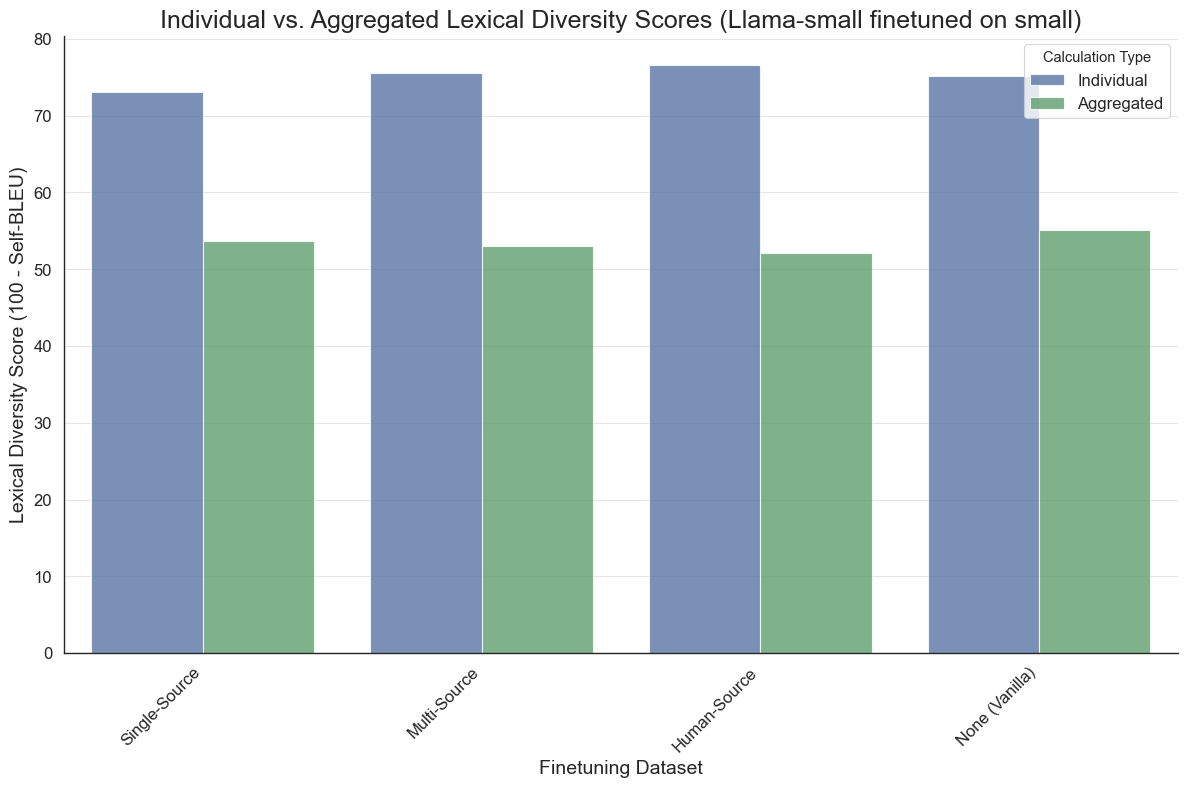


--- Lexical Diversity Statistics (Individual Responses) ---
Single-Source:
  Mean: 73.08, Median: 74.09, Variance: 285.86
Multi-Source:
  Mean: 75.49, Median: 77.34, Variance: 254.83
Human-Source:
  Mean: 76.55, Median: 85.19, Variance: 479.96
None (Vanilla):
  Mean: 75.12, Median: 76.28, Variance: 228.96

--- Levene's Test for Variance Homogeneity ---
Statistic: 16.95, p-value: 0.0000
Result: Variances are significantly different (p < 0.05). Performing pairwise tests.

Pairwise Levene's Tests:
  Single-Source vs Multi-Source: p-value = 0.0816
  Single-Source vs Human-Source: p-value = 0.0003 (Significant)
  Single-Source vs None (Vanilla): p-value = 0.0004 (Significant)
  Multi-Source vs Human-Source: p-value = 0.0000 (Significant)
  Multi-Source vs None (Vanilla): p-value = 0.0756
  Human-Source vs None (Vanilla): p-value = 0.0000 (Significant)

--- Kruskal-Wallis H-Test --- 
H-statistic: 66.20, p-value: 0.0000
Result: At least one dataset's distribution is significantly different (

In [26]:
# --- Configuration ---
MODEL_SIZE = "small"
BASE_DATA_DIR = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/{MODEL_SIZE}/lex_div"
N_GRAM = 3

# --- Data Loading ---
def load_bleu_data(base_path, mode, n_gram, size="Small"):
    """Loads Self-BLEU data from JSONL files into a DataFrame."""
    data_dir = os.path.join(base_path, f"self_bleu_{mode}_{n_gram}", size)
    if not os.path.exists(data_dir):
        print(f"Directory not found: {data_dir}")
        return pd.DataFrame()
        
    records = []
    for filename in os.listdir(data_dir):
        if filename.endswith(".jsonl"):
            with open(os.path.join(data_dir, filename), 'r') as f:
                for line in f:
                    records.append(json.loads(line))
    return pd.DataFrame(records)

df_individual = load_bleu_data(BASE_DATA_DIR, 'individual', N_GRAM)
df_aggregated = load_bleu_data(BASE_DATA_DIR, 'aggregated', N_GRAM)

# --- Data Mapping and Sorting ---
def get_finetuning_dataset_name(source):
    """Maps a source name to a human-readable finetuning dataset name."""
    if 'single' in source:
        return 'Single-Source'
    if 'multi' in source:
        return 'Multi-Source'
    if 'human' in source:
        return 'Human-Source'
    if 'dolly' in source.lower():
        return 'None (Vanilla)'
    return 'Unknown'

df_individual['Finetuning Dataset'] = df_individual['source'].apply(get_finetuning_dataset_name)
df_aggregated['Finetuning Dataset'] = df_aggregated['source'].apply(get_finetuning_dataset_name)

category_order = ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)']

df_individual['Finetuning Dataset'] = pd.Categorical(df_individual['Finetuning Dataset'], categories=category_order, ordered=True)
df_aggregated['Finetuning Dataset'] = pd.Categorical(df_aggregated['Finetuning Dataset'], categories=category_order, ordered=True)

df_individual = df_individual.sort_values('Finetuning Dataset').reset_index(drop=True)
df_aggregated = df_aggregated.sort_values('Finetuning Dataset').reset_index(drop=True)

# --- Summary Table ---
summary_df = pd.merge(
    df_individual[['Finetuning Dataset', 'average_lexical_diversity']],
    df_aggregated[['Finetuning Dataset', 'average_lexical_diversity']],
    on='Finetuning Dataset',
    suffixes=('_individual', '_aggregated')
)

summary_df.rename(columns={
    'average_lexical_diversity_individual': 'Individual Score',
    'average_lexical_diversity_aggregated': 'Aggregated Score'
}, inplace=True)

summary_df = summary_df[['Finetuning Dataset', 'Individual Score', 'Aggregated Score']]

print("--- Lexical Diversity Scores Summary ---")
print(summary_df.to_string(index=False))


# --- Visualization ---
plt.figure(figsize=(12, 8))
plot_data = pd.concat([
    df_individual.assign(type='Individual'),
    df_aggregated.assign(type='Aggregated')
])

sns.barplot(
    data=plot_data,
    x='Finetuning Dataset',
    y='average_lexical_diversity',
    hue='type',
    alpha=0.8,
    order=category_order
)

plt.title('Individual vs. Aggregated Lexical Diversity Scores (Llama-small finetuned on small)', fontsize=18)
plt.xlabel('Finetuning Dataset', fontsize=14)
plt.ylabel('Lexical Diversity Score (100 - Self-BLEU)', fontsize=14)
plt.xticks(
    rotation=45,
    ha='right',
    fontsize=12
)
plt.yticks(fontsize=12)
plt.legend(title='Calculation Type', fontsize=12)
plt.tight_layout()
plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/small/bar_lex_div_8b_ind_aggr.png")
plt.show()


# --- Statistical Analysis ---
if 'lexical_diversity_scores' not in df_individual.columns:
    print("\nColumn 'lexical_diversity_scores' not found. Cannot perform detailed statistical analysis.")
else:
    lex_div_scores = df_individual['lexical_diversity_scores'].tolist()
    dataset_names = df_individual['Finetuning Dataset'].tolist()

    print("\n--- Lexical Diversity Statistics (Individual Responses) ---")
    scores_dict = {name: scores for name, scores in zip(dataset_names, lex_div_scores)}
    for name in category_order:
        scores = scores_dict.get(name)
        if scores is not None:
            mean, median, var = np.mean(scores), np.median(scores), np.var(scores)
            print(f"{name}:\n  Mean: {mean:.2f}, Median: {median:.2f}, Variance: {var:.2f}")

    alpha = 0.05
    ordered_scores = [scores_dict[name] for name in category_order if name in scores_dict]

    if len(ordered_scores) > 1:
        levene_stat, levene_p = stats.levene(*ordered_scores)
        print(f"\n--- Levene's Test for Variance Homogeneity ---\nStatistic: {levene_stat:.2f}, p-value: {levene_p:.4f}")
        if levene_p < alpha:
            print(f"Result: Variances are significantly different (p < {alpha}). Performing pairwise tests.")
            
            print("\nPairwise Levene's Tests:")
            for (name1), (name2) in itertools.combinations(category_order, 2):
                if name1 in scores_dict and name2 in scores_dict:
                    stat, p_val = stats.levene(scores_dict[name1], scores_dict[name2])
                    print(f"  {name1} vs {name2}: p-value = {p_val:.4f}{' (Significant)' if p_val < alpha else ''}")
        else:
            print(f"Result: Variances are not significantly different (p >= {alpha}).")

    if len(ordered_scores) > 1:
        kruskal_h, kruskal_p = stats.kruskal(*ordered_scores)
        print(f"\n--- Kruskal-Wallis H-Test --- \nH-statistic: {kruskal_h:.2f}, p-value: {kruskal_p:.4f}")
        if kruskal_p < alpha:
            print(f"Result: At least one dataset's distribution is significantly different (p < {alpha}). Performing post-hoc tests.")
            
            n_comparisons = len(category_order) * (len(category_order) - 1) // 2
            corrected_alpha = alpha / n_comparisons if n_comparisons > 0 else alpha
            
            print(f"\nPairwise Mann-Whitney U Tests (Bonferroni corrected alpha={corrected_alpha:.4f}):")
            for (name1), (name2) in itertools.combinations(category_order, 2):
                 if name1 in scores_dict and name2 in scores_dict:
                    stat, p_val = stats.mannwhitneyu(scores_dict[name1], scores_dict[name2], alternative='two-sided')
                    print(f"  {name1} vs {name2}: U-stat={stat:.1f}, p-value={p_val:.4f}{' (Significant)' if p_val < corrected_alpha else ''}")
        else:
            print(f"Result: No significant difference between dataset distributions (p >= {alpha}).")

## Medium models

In [24]:
# --- Configuration ---
N_GRAM = 3
SAMPLE_NUMBER = 1500
SAVE_RESULTS = True
MODEL_SIZE = "medium"
FINETUNE_SIZE = "large"
BASE_DATA_DIR = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1"

# Using new, corrected file paths
model_paths = {
    "Medium": [
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_llama_70b_single_source_{FINETUNE_SIZE}.jsonl",
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_llama_70b_multi_source_{FINETUNE_SIZE}.jsonl",
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_llama_70b_human_source.jsonl",
        "/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_test_Llama.jsonl"
    ]
}

output_dir_template = f"{BASE_DATA_DIR}/{MODEL_SIZE}/lex_div/self_bleu_{{mode}}_{{n_gram}}_{FINETUNE_SIZE}"

# --- Run Calculations ---
# Calculate scores for individual responses
calculate_self_bleu_scores(
    data_paths=model_paths,
    output_dir_template=output_dir_template,
    mode='individual',
    sample_number=SAMPLE_NUMBER,
    save=SAVE_RESULTS,
    n_gram=N_GRAM
)

# Calculate scores for aggregated responses
calculate_self_bleu_scores(
    data_paths=model_paths,
    output_dir_template=output_dir_template,
    mode='aggregated',
    sample_number=100,  # Using 100 for aggregated as in original code
    save=SAVE_RESULTS,
    n_gram=N_GRAM
)

--- Running Self-BLEU Calculation (Mode: individual, N-gram: 3) ---
Processing Medium models...


  Files for Medium:   0%|          | 0/4 [00:00<?, ?it/s]

  Files for Medium:  25%|██▌       | 1/4 [00:06<00:18,  6.29s/it]

  Files for Medium:  50%|█████     | 2/4 [00:14<00:15,  7.57s/it]

  Files for Medium:  75%|███████▌  | 3/4 [00:16<00:04,  4.95s/it]

  Files for Medium: 100%|██████████| 4/4 [00:23<00:00,  5.78s/it]


--- Calculation complete. ---
--- Running Self-BLEU Calculation (Mode: aggregated, N-gram: 3) ---
Processing Medium models...


  Files for Medium: 100%|██████████| 4/4 [02:35<00:00, 38.91s/it]

--- Calculation complete. ---


--- Lexical Diversity Scores Summary ---
Finetuning Dataset  Individual Score  Aggregated Score
     Single-Source         77.540968         57.206718
      Multi-Source         78.768981         61.683060
      Human-Source         80.559722         61.461994
    None (Vanilla)         78.109452         58.386605


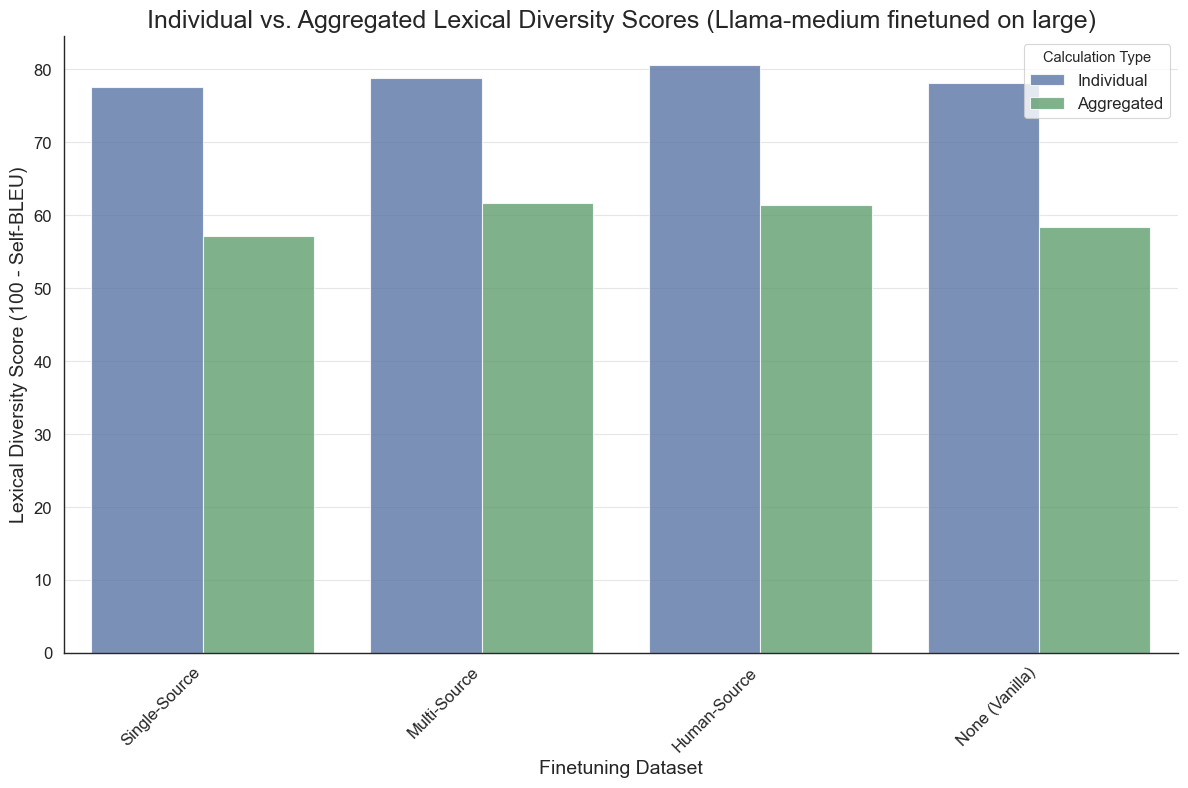


--- Lexical Diversity Statistics (Individual Responses) ---
Single-Source:
  Mean: 77.54, Median: 79.16, Variance: 200.11
Multi-Source:
  Mean: 78.77, Median: 80.36, Variance: 191.64
Human-Source:
  Mean: 80.56, Median: 86.87, Variance: 309.08
None (Vanilla):
  Mean: 78.11, Median: 78.94, Variance: 172.67

--- Levene's Test for Variance Homogeneity ---
Statistic: 6.73, p-value: 0.0002
Result: Variances are significantly different (p < 0.05). Performing pairwise tests.

Pairwise Levene's Tests:
  Single-Source vs Multi-Source: p-value = 0.2180
  Single-Source vs Human-Source: p-value = 0.0189 (Significant)
  Single-Source vs None (Vanilla): p-value = 0.0344 (Significant)
  Multi-Source vs Human-Source: p-value = 0.0016 (Significant)
  Multi-Source vs None (Vanilla): p-value = 0.4303
  Human-Source vs None (Vanilla): p-value = 0.0001 (Significant)

--- Kruskal-Wallis H-Test --- 
H-statistic: 65.02, p-value: 0.0000
Result: At least one dataset's distribution is significantly different (p

In [25]:
# --- Configuration ---
MODEL_SIZE = "medium"
FINETUNE_SIZE = "large"
SAVE_PLOT = True
BASE_DATA_DIR = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/{MODEL_SIZE}/lex_div"
N_GRAM = 3

# --- Data Loading ---
def load_bleu_data(base_path, mode, n_gram, size="Medium"):
    """Loads Self-BLEU data from JSONL files into a DataFrame."""
    data_dir = os.path.join(base_path, f"self_bleu_{mode}_{n_gram}_{FINETUNE_SIZE}", size)
    if not os.path.exists(data_dir):
        print(f"Directory not found: {data_dir}")
        return pd.DataFrame()
        
    records = []
    for filename in os.listdir(data_dir):
        if filename.endswith(".jsonl"):
            with open(os.path.join(data_dir, filename), 'r') as f:
                for line in f:
                    records.append(json.loads(line))
    return pd.DataFrame(records)

df_individual = load_bleu_data(BASE_DATA_DIR, 'individual', N_GRAM)
df_aggregated = load_bleu_data(BASE_DATA_DIR, 'aggregated', N_GRAM)

# --- Data Mapping and Sorting ---
def get_finetuning_dataset_name(source):
    """Maps a source name to a human-readable finetuning dataset name."""
    if 'single_source' in source:
        return 'Single-Source'
    if 'multi_source' in source:
        return 'Multi-Source'
    if 'human_source' in source:
        return 'Human-Source'
    if 'dolly' in source.lower(): # Check for 'dolly' case-insensitively
        return 'None (Vanilla)'
    return 'Unknown' # Fallback for any other cases

# Apply the mapping to create a new column
df_individual['Finetuning Dataset'] = df_individual['source'].apply(get_finetuning_dataset_name)
df_aggregated['Finetuning Dataset'] = df_aggregated['source'].apply(get_finetuning_dataset_name)

# Define the desired order for plotting
category_order = ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)']

# Set the category type with the specified order to ensure correct sorting in plots
df_individual['Finetuning Dataset'] = pd.Categorical(df_individual['Finetuning Dataset'], categories=category_order, ordered=True)
df_aggregated['Finetuning Dataset'] = pd.Categorical(df_aggregated['Finetuning Dataset'], categories=category_order, ordered=True)

# Sort the dataframes based on the new categorical column
df_individual = df_individual.sort_values('Finetuning Dataset').reset_index(drop=True)
df_aggregated = df_aggregated.sort_values('Finetuning Dataset').reset_index(drop=True)


# --- Summary Table ---
# Create a summary table by merging the two dataframes
summary_df = pd.merge(
    df_individual[['Finetuning Dataset', 'average_lexical_diversity']],
    df_aggregated[['Finetuning Dataset', 'average_lexical_diversity']],
    on='Finetuning Dataset',
    suffixes=('_individual', '_aggregated')
)

# Rename columns for clarity
summary_df.rename(columns={
    'average_lexical_diversity_individual': 'Individual Score',
    'average_lexical_diversity_aggregated': 'Aggregated Score'
}, inplace=True)

# Reorder columns and print the final table
summary_df = summary_df[['Finetuning Dataset', 'Individual Score', 'Aggregated Score']]

print("--- Lexical Diversity Scores Summary ---")
print(summary_df.to_string(index=False))


# --- Visualization ---
plt.figure(figsize=(12, 8))
plot_data = pd.concat([
    df_individual.assign(type='Individual'),
    df_aggregated.assign(type='Aggregated')
])

sns.barplot(
    data=plot_data,
    x='Finetuning Dataset', # Use the new column for x-axis
    y='average_lexical_diversity',
    hue='type',
    alpha=0.8,
    order=category_order # Ensure barplot uses the correct order
)

plt.title(f'Individual vs. Aggregated Lexical Diversity Scores (Llama-{MODEL_SIZE} finetuned on {FINETUNE_SIZE})', fontsize=18)
plt.xlabel('Finetuning Dataset', fontsize=14)
plt.ylabel('Lexical Diversity Score (100 - Self-BLEU)', fontsize=14)
plt.xticks(
    rotation=45,
    ha='right',
    fontsize=12
)
plt.yticks(fontsize=12)
plt.legend(title='Calculation Type', fontsize=12)
plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/bar_lex_div_70b_ind_aggr_{FINETUNE_SIZE}.png")
plt.show()


# --- Statistical Analysis ---
# Ensure 'lexical_diversity_scores' exists before proceeding
if 'lexical_diversity_scores' not in df_individual.columns:
    print("\nColumn 'lexical_diversity_scores' not found. Cannot perform detailed statistical analysis.")
else:
    # Use the 'Finetuning Dataset' column for names, ensuring it's in the correct order
    lex_div_scores = df_individual['lexical_diversity_scores'].tolist()
    dataset_names = df_individual['Finetuning Dataset'].tolist()

    print("\n--- Lexical Diversity Statistics (Individual Responses) ---")
    # Create a mapping from dataset name to scores for correct association
    scores_dict = {name: scores for name, scores in zip(dataset_names, lex_div_scores)}
    for name in category_order: # Iterate in the desired order
        scores = scores_dict.get(name)
        if scores is not None:
            mean, median, var = np.mean(scores), np.median(scores), np.var(scores)
            print(f"{name}:\n  Mean: {mean:.2f}, Median: {median:.2f}, Variance: {var:.2f}")

    alpha = 0.05

    # Order scores for statistical tests according to category_order
    ordered_scores = [scores_dict[name] for name in category_order if name in scores_dict]

    # Levene's test for homogeneity of variances
    if len(ordered_scores) > 1:
        levene_stat, levene_p = stats.levene(*ordered_scores)
        print(f"\n--- Levene's Test for Variance Homogeneity ---\nStatistic: {levene_stat:.2f}, p-value: {levene_p:.4f}")
        if levene_p < alpha:
            print(f"Result: Variances are significantly different (p < {alpha}). Performing pairwise tests.")
            
            print("\nPairwise Levene's Tests:")
            for (name1), (name2) in itertools.combinations(category_order, 2):
                if name1 in scores_dict and name2 in scores_dict:
                    stat, p_val = stats.levene(scores_dict[name1], scores_dict[name2])
                    print(f"  {name1} vs {name2}: p-value = {p_val:.4f}{' (Significant)' if p_val < alpha else ''}")

        else:
            print(f"Result: Variances are not significantly different (p >= {alpha}).")

    # Kruskal-Wallis H-test for comparing distributions
    if len(ordered_scores) > 1:
        kruskal_h, kruskal_p = stats.kruskal(*ordered_scores)
        print(f"\n--- Kruskal-Wallis H-Test --- \nH-statistic: {kruskal_h:.2f}, p-value: {kruskal_p:.4f}")
        if kruskal_p < alpha:
            print(f"Result: At least one dataset's distribution is significantly different (p < {alpha}). Performing post-hoc tests.")
            
            n_comparisons = len(category_order) * (len(category_order) - 1) // 2
            corrected_alpha = alpha / n_comparisons if n_comparisons > 0 else alpha
            
            print(f"\nPairwise Mann-Whitney U Tests (Bonferroni corrected alpha={corrected_alpha:.4f}):")
            for (name1), (name2) in itertools.combinations(category_order, 2):
                 if name1 in scores_dict and name2 in scores_dict:
                    stat, p_val = stats.mannwhitneyu(scores_dict[name1], scores_dict[name2], alternative='two-sided')
                    print(f"  {name1} vs {name2}: U-stat={stat:.1f}, p-value={p_val:.4f}{' (Significant)' if p_val < corrected_alpha else ''}")

        else:
            print(f"Result: No significant difference between dataset distributions (p >= {alpha}).")